In [1]:
import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


In [2]:
portfolio = {
    '종목명': ['삼성전자', 'SK하이닉스', '에이피알','삼성전기','예수금(현금)'],
    '종목코드': ['005930', '000660', '278470','009150','CASH'], 
    '수량': [29, 6, 12,7,3355274]
}

df = pd.DataFrame(portfolio)


In [3]:
def get_latest_close(ticker):
    # 종목코드가 'CASH'인 경우 종가를 1원으로 고정
    if ticker == 'CASH':
        return 1    
    try:
        price_data = fdr.DataReader(ticker) 
        return price_data['Close'].iloc[-1] # 가장 마지막(최신) 종가 반환
    except Exception as e:
        print(f"{ticker} 데이터 수집 오류: {e}")
        return 0

In [4]:
df['종가'] = df['종목코드'].apply(get_latest_close)

In [5]:
df['평가금액'] = df['종가'] * df['수량']

total_portfolio_value = df['평가금액'].sum() 

df['비중(%)'] = ((df['평가금액'] / total_portfolio_value) * 100).round(2)

# 결과 확인
print(f"총 포트폴리오 평가금액: {total_portfolio_value:,.0f}원\n")
print(df)

총 포트폴리오 평가금액: 28,868,274원

       종목명    종목코드       수량       종가     평가금액  비중(%)
0     삼성전자  005930       29   226000  6554000  22.70
1   SK하이닉스  000660        6  1293000  7758000  26.87
2     에이피알  278470       12   451000  5412000  18.75
3     삼성전기  009150        7   827000  5789000  20.05
4  예수금(현금)    CASH  3355274        1  3355274  11.62


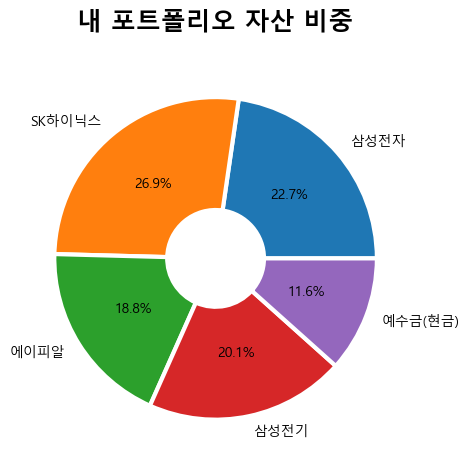

In [6]:
import platform


# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

# 3. 파이 차트 그리기
# 비중(%) 데이터와 종목명 라벨을 매칭합니다.
plt.pie(
    df['비중(%)'], 
    labels=df['종목명'], 
    autopct='%1.1f%%',         # 백분율을 소수점 첫째 자리까지 표시
    wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 3} # 도넛 모양 스타일 및 테두리
)

# 4. 제목 추가 및 출력
plt.title('내 포트폴리오 자산 비중', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

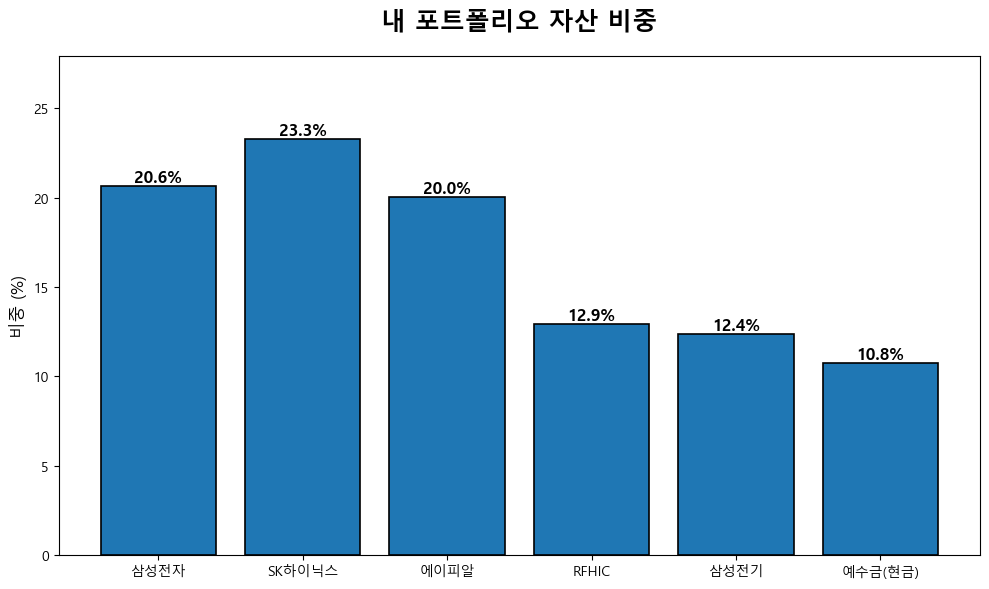

In [7]:

# 2. 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 3. 막대그래프 그리기 (x축: 종목명, y축: 비중)
# 색상은 파이 차트와 동일하게 설정하거나 하나로 통일할 수 있습니다.
bars = plt.bar(
    df['종목명'], 
    df['비중(%)'], 
    edgecolor='black', # 막대 테두리 추가
    linewidth=1.2
)

# 4. 막대 위에 정확한 수치(%) 글씨로 표시하기
for bar in bars:
    height = bar.get_height()
    # 막대의 중앙 상단에 텍스트 위치시킴
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height, 
        f'{height:.1f}%', 
        ha='center',       # 가로 중앙 정렬
        va='bottom',       # 세로 하단 정렬 (막대 바로 위)
        fontsize=12,
        fontweight='bold'
    )

# 5. 축 라벨 및 제목 설정
plt.title('내 포트폴리오 자산 비중', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('비중 (%)', fontsize=12)


# 6. y축 상단 여백 확보 및 출력
plt.ylim(0, df['비중(%)'].max() * 1.2) # 가장 높은 막대 위의 글씨가 잘리지 않도록 여백을 20% 추가
plt.tight_layout()
plt.show()